In [1]:
import jax 
import jax.numpy as jnp

import jax.linear_util as lu
import jax.api_util as api_util


In [2]:
def log_potential(x, z):
    x_mean = z**2
    return -0.5 * (x_mean - x) ** 2 + -0.5*z**2


In [3]:
from probjax.inference.mcmc import MCMC
from probjax.inference.transition_kernels import UniformKernel, GaussianKernel, LangevinDynKernel, HMCKernel, SliceKernel

In [29]:
x_obs = 8.
mcmc = MCMC(HMCKernel(), lambda z: log_potential(x_obs, z), jax.random.normal(jax.random.PRNGKey(0), (1000,),))

In [36]:
samples = mcmc.run(jax.random.PRNGKey(0), 10000)

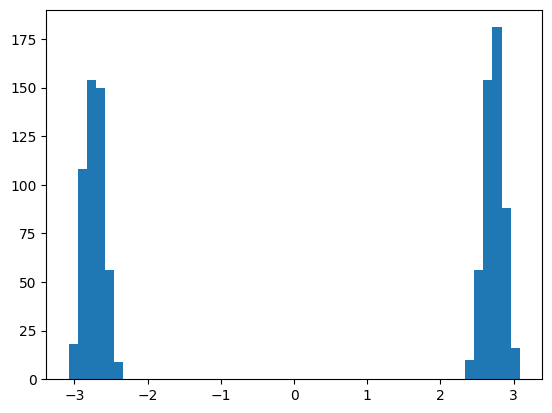

In [37]:
import matplotlib.pyplot as plt

_ = plt.hist(samples, bins=50)